# LightGBM

In [ ]:
import h5py
import numpy as np
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# SELECT CLASSIFICATION MODE
# ==========================================================
classification_mode = "3class"   # "binary", "3class", "5class"

# ==========================================================
# 1. LOAD DATA
# ==========================================================
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================
valid_labels = [0,1,2,3,5]

mask_tr = np.isin(y_train, valid_labels)
mask_te = np.isin(y_test, valid_labels)

X_train = X_train[mask_tr]
y_train = y_train[mask_tr]
X_test  = X_test[mask_te]
y_test  = y_test[mask_te]

# ==========================================================
# 3. LABEL MAPPING
# ==========================================================

if classification_mode == "binary":

    sleep_stages = [1,2,3,5]
    y_train_new = np.where(np.isin(y_train, sleep_stages),0,1)
    y_test_new  = np.where(np.isin(y_test, sleep_stages),0,1)
    target_names = ["Sleep","Wake"]

elif classification_mode == "3class":

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    y_train_new[np.isin(y_train,[1,2,3])] = 1
    y_test_new[np.isin(y_test,[1,2,3])] = 1

    y_train_new[y_train == 5] = 2
    y_test_new[y_test == 5] = 2

    target_names = ["Wake","NREM","REM"]

elif classification_mode == "5class":

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)
    target_names = ["Wake","N1","N2","N3","REM"]

# ==========================================================
# 4. FEATURE GROUPING
# ==========================================================

EEG = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG = [f for f in feature_names if f.startswith("EOG")]
EMG = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {
    "EEG": EEG,
    "EEG + EOG": EEG + EOG,
    "EEG + EOG + EMG": EEG + EOG + EMG,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG,
    "All PSG features": EEG + EOG + EMG + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}

# ==========================================================
# 5. TRAIN & TEST LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")

    if len(fs) == 0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_tr = X_train[:, idx]
    X_te = X_test[:, idx]

    y_tr = y_train_new
    y_te = y_test_new

    start_total = time.time()

    # ======================================================
    # BALANCING
    # ======================================================
    if classification_mode != "5class":

        classes = np.unique(y_tr)
        max_samples = max([np.sum(y_tr == c) for c in classes])

        X_bal, y_bal = [], []

        for c in classes:

            X_c = X_tr[y_tr == c]
            y_c = y_tr[y_tr == c]

            if len(X_c) < max_samples:
                X_res, y_res = resample(
                    X_c, y_c,
                    replace=True,
                    n_samples=max_samples,
                    random_state=42
                )
            else:
                X_res, y_res = X_c, y_c

            X_bal.append(X_res)
            y_bal.append(y_res)

        X_tr_bal = np.vstack(X_bal)
        y_tr_bal = np.hstack(y_bal)

    else:
        X_tr_bal, y_tr_bal = X_tr, y_tr

    # ======================================================
    # SCALE
    # ======================================================
    scaler = StandardScaler()

    X_tr_bal = scaler.fit_transform(X_tr_bal)
    X_te = scaler.transform(X_te)

    # ======================================================
    # MODEL
    # ======================================================
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_tr_bal, y_tr_bal)

    y_pred = model.predict(X_te)

    # ======================================================
    # METRICS
    # ======================================================
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro')
    kappa = cohen_kappa_score(y_te, y_pred)

    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"Kappa: {kappa:.3f}")

    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_te, y_pred))

    print(f"\nTotal time: {time.time()-start_total:.2f} sec")

    results[name] = {
        "Accuracy": acc,
        "F1_macro": f1,
        "Kappa": kappa
    }

# ==========================================================
# 6. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("-------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1':>6s} | {'Kappa':>6s}")

for k,v in results.items():
    print(f"{k:20s} | {v['Accuracy']:6.3f} | {v['F1_macro']:6.3f} | {v['Kappa']:6.3f}")

Train shape: (46398, 129)
Test shape: (11600, 129)

Running Wake vs NREM vs REM

Training with modality: EEG
Number of features: 60
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15300
[LightGBM] [Info] Number of data points in the train set: 92148, number of used features: 60
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training time: 10.90 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.79      0.91      0.85      1872
        NREM       0.96      0.90      0.93      7679
         REM       0.80      0.88      0.84      2029

    accuracy                           0.90     11580
   macro avg       0.85      0.90      0.87     11580
weighted avg       0.91      0.90      0.

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21420
[LightGBM] [Info] Number of data points in the train set: 92148, number of used features: 84
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training time: 13.62 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.82      0.91      0.86      1872
        NREM       0.97      0.92      0.94      7679
         REM       0.84      0.90      0.87      2029

    accuracy                           0.92     11580
   macro avg       0.87      0.91      0.89     11580
weighted avg       0.92      0.92      0.92     11580

Wake       | Sensitivity: 0.913 | Specificity: 0.961
NREM       | Sensitivity: 0.920 | Specificity: 0.937
REM        |

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22185
[LightGBM] [Info] Number of data points in the train set: 92148, number of used features: 87
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training time: 16.31 sec


...

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26265
[LightGBM] [Info] Number of data points in the train set: 92148, number of used features: 103
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training time: 22.08 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.82      0.92      0.87      1872
        NREM       0.97      0.93      0.95      7679
         REM       0.85      0.90      0.87      2029

    accuracy                           0.92     11580
   macro avg       0.88      0.91      0.90     11580
weighted avg       0.92      0.92      0.92     11580

Wake       | Sensitivity: 0.920 | Specificity: 0.961
NREM       | Sensitivity: 0.926 | Specificity: 0.940
REM        

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026324 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30690
[LightGBM] [Info] Number of data points in the train set: 92148, number of used features: 121
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training time: 17.97 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.83      0.93      0.88      1872
        NREM       0.97      0.93      0.95      7679
         REM       0.86      0.90      0.88      2029

    accuracy                           0.92     11580
   macro avg       0.89      0.92      0.90     11580
weighted avg       0.93      0.92      0.93     11580

Wake       | Sensitivity: 0.928 | Specificity: 0.965
NREM       | Sensitivity: 0.932 | Specificity: 0.941
REM        

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


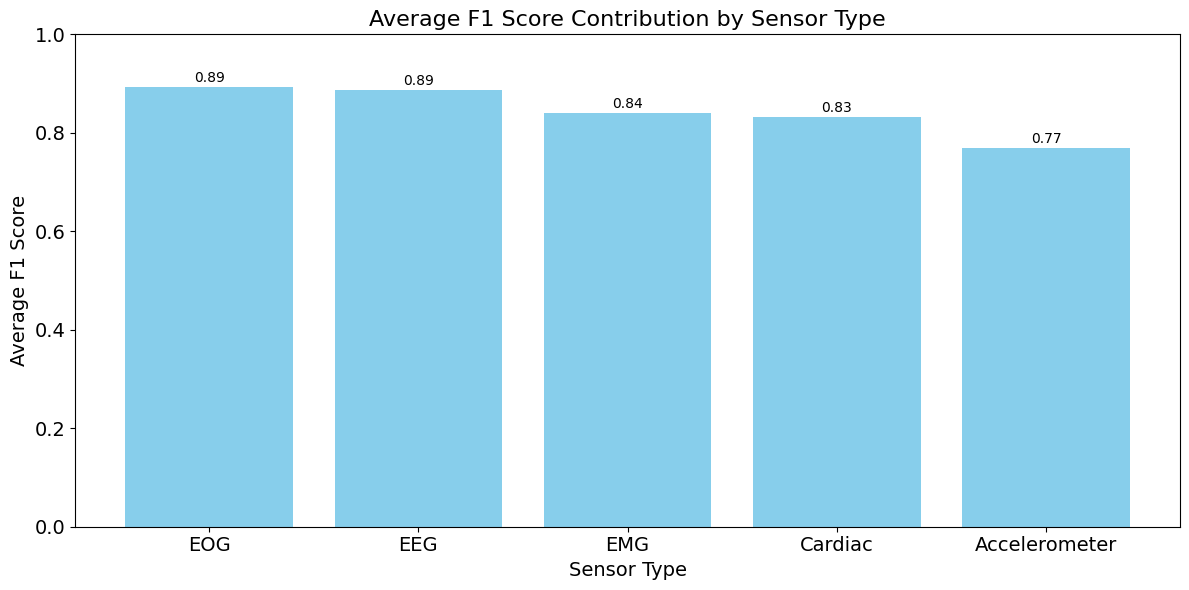

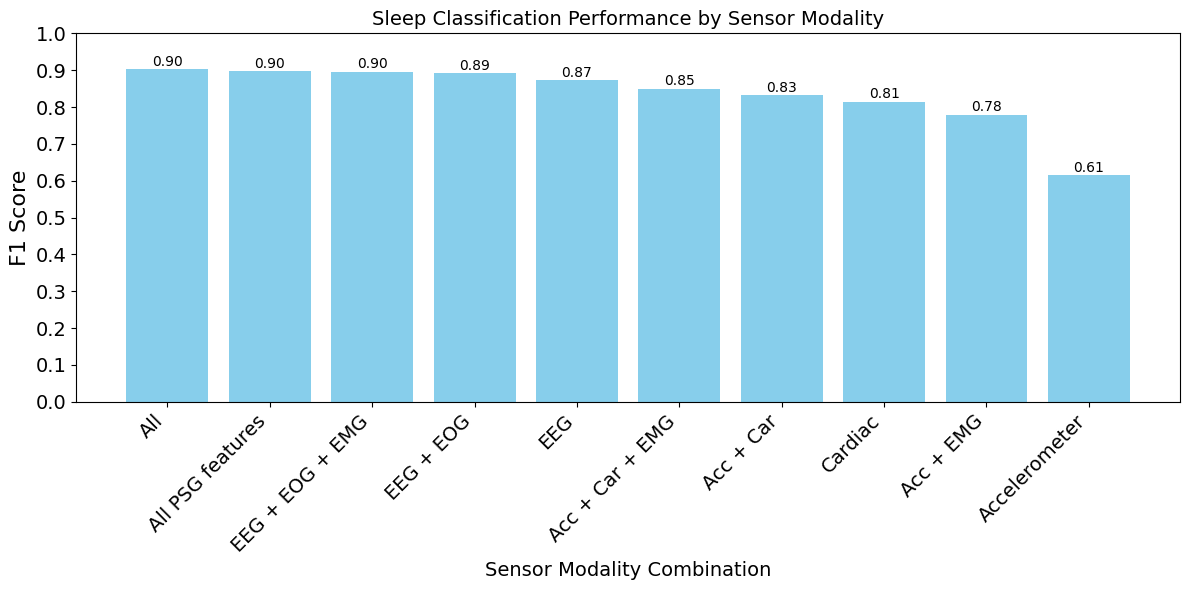



====================== FINAL MODALITY COMPARISON ========================
------------------------------------------------------------------------------
Modality             |    Acc | F1-macro |  Kappa |  Sens(W) |  Spec(S)
-------------------------------------------------------------------------------
EEG                  |  0.900 |    0.872 |  0.809 |    0.908 |    0.954
EEG + EOG            |  0.916 |    0.892 |  0.837 |    0.913 |    0.961
EEG + EOG + EMG      |  0.919 |    0.895 |  0.843 |    0.921 |    0.961
Cardiac              |  0.851 |    0.814 |  0.722 |    0.871 |    0.929
Accelerometer        |  0.664 |    0.614 |  0.426 |    0.698 |    0.781
Acc + EMG            |  0.819 |    0.779 |  0.666 |    0.834 |    0.922
Acc + Car            |  0.866 |    0.832 |  0.749 |    0.879 |    0.938
Acc + Car + EMG      |  0.880 |    0.849 |  0.773 |    0.899 |    0.945
All PSG features     |  0.920 |    0.897 |  0.846 |    0.920 |    0.961
All                  |  0.925 |    0.902 |  0

In [ ]:
import h5py
import numpy as np
import lightgbm as lgb
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample


# ==========================================================
# SELECT CLASSIFICATION MODE
# ==========================================================
classification_mode = "3class"   # "binary", "3class", "5class"


# ==========================================================
# 1. LOAD DATA
# ==========================================================
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================
valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test  = X_test[test_mask]
y_test  = y_test[test_mask]


# ==========================================================
# 3. LABEL MAPPING
# ==========================================================

if classification_mode == "binary":

    print("\nRunning Binary Sleep vs Wake")

    sleep_stages = [1,2,3,5]

    y_train_new = np.where(np.isin(y_train, sleep_stages),0,1)
    y_test_new  = np.where(np.isin(y_test, sleep_stages),0,1)

    target_names = ["Sleep","Wake"]


elif classification_mode == "3class":

    print("\nRunning Wake vs NREM vs REM")

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    y_train_new[np.isin(y_train,[1,2,3])] = 1
    y_test_new[np.isin(y_test,[1,2,3])] = 1

    y_train_new[y_train == 5] = 2
    y_test_new[y_test == 5] = 2

    target_names = ["Wake","NREM","REM"]


elif classification_mode == "5class":

    print("\nRunning Full 5-Stage Classification")

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    target_names = ["Wake","N1","N2","N3","REM"]


# ==========================================================
# 4. FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {

    "EEG": EEG_features,
    "EEG + EOG": EEG_features + EOG_features,
    "EEG + EOG + EMG": EEG_features + EOG_features + EMG_features,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": EEG_features + EOG_features + EMG_features + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}


# ==========================================================
# 5. MODALITY LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:, idx]
    X_test_fs = X_test[:, idx]


    # ======================================================
    # BALANCING
    # ======================================================

    if classification_mode != "5class":

        unique_classes = np.unique(y_train_new)
        max_samples = max([np.sum(y_train_new == c) for c in unique_classes])

        X_bal, y_bal = [], []

        for c in unique_classes:

            X_c = X_train_fs[y_train_new == c]
            y_c = y_train_new[y_train_new == c]

            if len(X_c) < max_samples:

                X_res, y_res = resample(
                    X_c, y_c,
                    replace=True,
                    n_samples=max_samples,
                    random_state=42
                )

            else:

                X_res, y_res = X_c, y_c

            X_bal.append(X_res)
            y_bal.append(y_res)

        X_train_final = np.vstack(X_bal)
        y_train_final = np.hstack(y_bal)

    else:

        X_train_final = X_train_fs
        y_train_final = y_train_new


    # ======================================================
    # SCALING
    # ======================================================

    scaler = StandardScaler()

    X_train_final = scaler.fit_transform(X_train_final)
    X_test_fs = scaler.transform(X_test_fs)


    # ======================================================
    # MODEL
    # ======================================================

    if classification_mode == "binary":

        model = lgb.LGBMClassifier(
            objective='binary',
            class_weight='balanced',
            num_leaves=70,
            learning_rate=0.05,
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )

    else:

        model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=len(np.unique(y_train_new)),
            class_weight='balanced',
            num_leaves=70,
            learning_rate=0.05,
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )


    # ======================================================
    # TRAIN
    # ======================================================

    start = time.time()

    model.fit(X_train_final, y_train_final)

    print(f"Training time: {time.time()-start:.2f} sec")


    # ======================================================
    # PREDICT
    # ======================================================

    y_pred = model.predict(X_test_fs)


    # ======================================================
    # METRICS
    # ======================================================

    acc = accuracy_score(y_test_new, y_pred)
    f1 = f1_score(y_test_new, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test_new, y_pred)

    cm = confusion_matrix(y_test_new, y_pred)

    #print("\nConfusion Matrix\n", cm)

    print("\nClassification Report\n")
    print(classification_report(y_test_new, y_pred, target_names=target_names))


    # ======================================================
    # STAGE-WISE SENSITIVITY & SPECIFICITY
    # ======================================================

    sensitivities = {}
    specificities = {}

    for i, label in enumerate(target_names):

        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        sens = TP / (TP + FN)
        spec = TN / (TN + FP)

        sensitivities[label] = sens
        specificities[label] = spec

        print(f"{label:10s} | Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")


    results[name] = {
        "Accuracy": acc,
        "F1_macro": f1,
        "Kappa": kappa,
        "Sensitivity": sensitivities,
        "Specificity": specificities
    }



import matplotlib.pyplot as plt

sensor_scores = {
    "EEG": [],
    "EOG": [],
    "EMG": [],
    "Cardiac": [],
    "Accelerometer": []
}

# Collect F1 scores for each sensor type
for modality, data in results.items():

    f1 = data["F1_macro"]

    if "EEG" in modality:
        sensor_scores["EEG"].append(f1)

    if "EOG" in modality:
        sensor_scores["EOG"].append(f1)

    if "EMG" in modality:
        sensor_scores["EMG"].append(f1)

    if "Car" in modality or "Cardiac" in modality:
        sensor_scores["Cardiac"].append(f1)

    if "Acc" in modality or "Accelerometer" in modality:
        sensor_scores["Accelerometer"].append(f1)


# Compute average F1 score for each sensor
avg_scores = {}

for sensor, values in sensor_scores.items():

    if len(values) > 0:
        avg_scores[sensor] = np.mean(values)
    else:
        avg_scores[sensor] = 0


labels = list(avg_scores.keys())
values = list(avg_scores.values())

# Sort sensors by score (descending)
sorted_idx = np.argsort(values)[::-1]

labels_sorted = [labels[i] for i in sorted_idx]
values_sorted = [values[i] for i in sorted_idx]

plt.figure(figsize=(12,6))

plt.bar(labels_sorted, values_sorted, color='skyblue')

plt.title("Average F1 Score Contribution by Sensor Type", fontsize=16)
plt.xlabel("Sensor Type", fontsize=14)
plt.ylabel("Average F1 Score", fontsize=14)

# Increase tick label sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.ylim(0,1)

for i,v in enumerate(values_sorted):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()


import numpy as np

# Extract modality names and F1 scores
modalities = list(results.keys())
f1_scores = [v["F1_macro"] for v in results.values()]

# Sort by F1 score (descending)
sorted_idx = np.argsort(f1_scores)[::-1]

modalities_sorted = [modalities[i] for i in sorted_idx]
f1_sorted = [f1_scores[i] for i in sorted_idx]

# Plot
plt.figure(figsize=(12,6))

plt.bar(modalities_sorted, f1_sorted, color='skyblue')

# Increase modality names (X-axis)
plt.xticks(rotation=45, ha='right', fontsize=14)

# Increase F1 axis numbers
plt.yticks(np.arange(0, 1.01, 0.10), fontsize=14)


plt.ylabel("F1 Score", fontsize=16)
plt.xlabel("Sensor Modality Combination", fontsize=14)
plt.title("Sleep Classification Performance by Sensor Modality", fontsize=14)

plt.ylim(0,1)

# Show value on top of bars
for i, v in enumerate(f1_sorted):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

# ==========================================================
# 6. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1_macro']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']['Wake']:8.3f} | "
          f"{v['Specificity']['Wake']:8.3f}")

print("--------------------------------------------------------------------------------")

# RF

In [3]:
import h5py
import numpy as np
import lightgbm as lgb
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# SELECT CLASSIFICATION MODE
# ==========================================================
classification_mode = "3class"   # "binary", "3class", "5class"


# ==========================================================
# 1. LOAD DATA
# ==========================================================
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================
valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test  = X_test[test_mask]
y_test  = y_test[test_mask]


# ==========================================================
# 3. LABEL MAPPING
# ==========================================================

if classification_mode == "binary":

    print("\nRunning Binary Sleep vs Wake")

    sleep_stages = [1,2,3,5]

    y_train_new = np.where(np.isin(y_train, sleep_stages),0,1)
    y_test_new  = np.where(np.isin(y_test, sleep_stages),0,1)

    target_names = ["Sleep","Wake"]


elif classification_mode == "3class":

    print("\nRunning Wake vs NREM vs REM")

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    y_train_new[np.isin(y_train,[1,2,3])] = 1
    y_test_new[np.isin(y_test,[1,2,3])] = 1

    y_train_new[y_train == 5] = 2
    y_test_new[y_test == 5] = 2

    target_names = ["Wake","NREM","REM"]


elif classification_mode == "5class":

    print("\nRunning Full 5-Stage Classification")

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    target_names = ["Wake","N1","N2","N3","REM"]


# ==========================================================
# 4. FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {

    "EEG": EEG_features,
    "EEG + EOG": EEG_features + EOG_features,
    "EEG + EOG + EMG": EEG_features + EOG_features + EMG_features,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": EEG_features + EOG_features + EMG_features + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}


# ==========================================================
# 5. MODALITY LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:, idx]
    X_test_fs = X_test[:, idx]


    
    # ======================================================
    # BALANCING
    # ======================================================

    if classification_mode != "5class":

        unique_classes = np.unique(y_train_new)
        max_samples = max([np.sum(y_train_new == c) for c in unique_classes])

        X_bal, y_bal = [], []

        for c in unique_classes:

            X_c = X_train_fs[y_train_new == c]
            y_c = y_train_new[y_train_new == c]

            if len(X_c) < max_samples:

                X_res, y_res = resample(
                    X_c, y_c,
                    replace=True,
                    n_samples=max_samples,
                    random_state=42
                )

            else:

                X_res, y_res = X_c, y_c

            X_bal.append(X_res)
            y_bal.append(y_res)

        X_train_final = np.vstack(X_bal)
        y_train_final = np.hstack(y_bal)

    else:

        X_train_final = X_train_fs
        y_train_final = y_train_new


    # ======================================================
    # SCALING
    # ======================================================

    scaler = StandardScaler()

    X_train_final = scaler.fit_transform(X_train_final)
    X_test_fs = scaler.transform(X_test_fs)
    

    # ======================================================
# FEATURE SELECTION
# ======================================================

# USE_FEATURE_SELECTION = True
# TOP_K = 80   # try 60, 80, 100

# if USE_FEATURE_SELECTION and X_train_final.shape[1] > TOP_K:

#     print(f"Applying feature selection (top {TOP_K})")

#     # Train temporary RF for feature importance
#     fs_model = RandomForestClassifier(
#         n_estimators=200,
#         random_state=42,
#         n_jobs=-1
#     )

#     fs_model.fit(X_train_final, y_train_final)

#     importances = fs_model.feature_importances_

#     # Get top K indices
#     top_idx = np.argsort(importances)[-TOP_K:]

#     # Reduce features
#     X_train_final = X_train_final[:, top_idx]
#     X_test_fs = X_test_fs[:, top_idx]

#     selected_features = [feature_names[idx[i]] for i in top_idx]

#     # Print top 15 features
#     print("\nTop 15 most important features:")
#     top15 = np.argsort(importances)[-15:][::-1]

#     for i in top15:
#         print(f"{feature_names[idx[i]]} -> {importances[i]:.4f}")

    # ======================================================
    # MODEL
    # ======================================================

    model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
        )

    # ======================================================
    # TRAIN
    # ======================================================

    start = time.time()

    model.fit(X_train_final, y_train_final)

    print(f"Training time: {time.time()-start:.2f} sec")


    # ======================================================
    # PREDICT
    # ======================================================

    y_pred = model.predict(X_test_fs)


    # ======================================================
    # METRICS
    # ======================================================

    acc = accuracy_score(y_test_new, y_pred)
    f1 = f1_score(y_test_new, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test_new, y_pred)

    cm = confusion_matrix(y_test_new, y_pred)

    #print("\nConfusion Matrix\n", cm)

    print("\nClassification Report\n")
    print(classification_report(y_test_new, y_pred, target_names=target_names))


    # ======================================================
    # STAGE-WISE SENSITIVITY & SPECIFICITY
    # ======================================================

    sensitivities = {}
    specificities = {}

    for i, label in enumerate(target_names):

        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        sens = TP / (TP + FN)
        spec = TN / (TN + FP)

        sensitivities[label] = sens
        specificities[label] = spec

        print(f"{label:10s} | Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")


    results[name] = {
        "Accuracy": acc,
        "F1_macro": f1,
        "Kappa": kappa,
        "Sensitivity": sensitivities,
        "Specificity": specificities
    }


# ==========================================================
# 6. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1_macro']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']['Wake']:8.3f} | "
          f"{v['Specificity']['Wake']:8.3f}")

print("--------------------------------------------------------------------------------")


Train shape: (46398, 129)
Test shape: (11600, 129)

Running Wake vs NREM vs REM

Training with modality: EEG
Number of features: 60
Training time: 31.62 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.78      0.90      0.84      1872
        NREM       0.95      0.90      0.93      7679
         REM       0.78      0.85      0.81      2029

    accuracy                           0.89     11580
   macro avg       0.84      0.88      0.86     11580
weighted avg       0.90      0.89      0.89     11580

Wake       | Sensitivity: 0.899 | Specificity: 0.952
NREM       | Sensitivity: 0.898 | Specificity: 0.916
REM        | Sensitivity: 0.847 | Specificity: 0.948

Training with modality: EEG + EOG
Number of features: 84
Training time: 35.66 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.80      0.90      0.85      1872
        NREM       0.96      0.91      0.93      7679
         

# SVM

In [6]:
import h5py
import numpy as np
import lightgbm as lgb
import time

from sklearn.calibration import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample
from sklearn.svm import SVC

# ==========================================================
# SELECT CLASSIFICATION MODE
# ==========================================================
classification_mode = "3class"   # "binary", "3class", "5class"


# ==========================================================
# 1. LOAD DATA
# ==========================================================
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================
valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test  = X_test[test_mask]
y_test  = y_test[test_mask]


# ==========================================================
# 3. LABEL MAPPING
# ==========================================================

if classification_mode == "binary":

    print("\nRunning Binary Sleep vs Wake")

    sleep_stages = [1,2,3,5]

    y_train_new = np.where(np.isin(y_train, sleep_stages),0,1)
    y_test_new  = np.where(np.isin(y_test, sleep_stages),0,1)

    target_names = ["Sleep","Wake"]


elif classification_mode == "3class":

    print("\nRunning Wake vs NREM vs REM")

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    y_train_new[np.isin(y_train,[1,2,3])] = 1
    y_test_new[np.isin(y_test,[1,2,3])] = 1

    y_train_new[y_train == 5] = 2
    y_test_new[y_test == 5] = 2

    target_names = ["Wake","NREM","REM"]


elif classification_mode == "5class":

    print("\nRunning Full 5-Stage Classification")

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    target_names = ["Wake","N1","N2","N3","REM"]


# ==========================================================
# 4. FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {

    "EEG": EEG_features,
    "EEG + EOG": EEG_features + EOG_features,
    "EEG + EOG + EMG": EEG_features + EOG_features + EMG_features,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": EEG_features + EOG_features + EMG_features + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}


# ==========================================================
# 5. MODALITY LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:, idx]
    X_test_fs = X_test[:, idx]


    # ======================================================
    # BALANCING
    # ======================================================

    if classification_mode != "5class":

        unique_classes = np.unique(y_train_new)
        max_samples = max([np.sum(y_train_new == c) for c in unique_classes])

        X_bal, y_bal = [], []

        for c in unique_classes:

            X_c = X_train_fs[y_train_new == c]
            y_c = y_train_new[y_train_new == c]

            if len(X_c) < max_samples:

                X_res, y_res = resample(
                    X_c, y_c,
                    replace=True,
                    n_samples=max_samples,
                    random_state=42
                )

            else:

                X_res, y_res = X_c, y_c

            X_bal.append(X_res)
            y_bal.append(y_res)

        X_train_final = np.vstack(X_bal)
        y_train_final = np.hstack(y_bal)

    else:

        X_train_final = X_train_fs
        y_train_final = y_train_new


    # ======================================================
    # SCALING
    # ======================================================

    scaler = StandardScaler()

    X_train_final = scaler.fit_transform(X_train_final)
    X_test_fs = scaler.transform(X_test_fs)

    # ======================================================
    # FEATURE SELECTION (NEW)
    # ======================================================

    # from sklearn.feature_selection import SelectKBest, f_classif
    
    # k = min(80, X_train_final.shape[1])  # try 80, or tune later

    # selector = SelectKBest(score_func=f_classif, k=k)

    # X_train_final = selector.fit_transform(X_train_final, y_train_final)
    # X_test_fs = selector.transform(X_test_fs)

    # # Optional: get selected feature names
    # selected_idx = selector.get_support(indices=True)
    # selected_features = [fs[i] for i in selected_idx]

    # print(f"Selected {len(selected_features)} features")
    # ======================================================
    # MODEL
    # ======================================================

    svm_params = {
    "C": 1.0,
    "class_weight": "balanced",
    "max_iter": 5000
     }


    # model = SVC(
    #     kernel='rbf',        # best general kernel
    #     C=5,                # regularization
    #     gamma='scale',       # kernel coefficient
    #     class_weight='balanced',
    #     probability=True,    # needed for multiclass
    #     random_state=42
    # )

    # ======================================================
    # TRAIN
    # ======================================================

    start = time.time()
    model = LinearSVC(**svm_params)
    model.fit(X_train_final, y_train_final)

    print(f"Training time: {time.time()-start:.2f} sec")

    # ======================================================
    # PREDICT
    # ======================================================

    y_pred = model.predict(X_test_fs)

    # ======================================================
    # METRICS
    # ======================================================

    acc = accuracy_score(y_test_new, y_pred)
    f1 = f1_score(y_test_new, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test_new, y_pred)

    cm = confusion_matrix(y_test_new, y_pred)

    #print("\nConfusion Matrix\n", cm)

    print("\nClassification Report\n")
    print(classification_report(y_test_new, y_pred, target_names=target_names))


    # ======================================================
    # STAGE-WISE SENSITIVITY & SPECIFICITY
    # ======================================================

    # sensitivities = {}
    # specificities = {}

    for i, label in enumerate(target_names):

        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        sens = TP / (TP + FN)
        spec = TN / (TN + FP)

        sensitivities[label] = sens
        specificities[label] = spec

        print(f"{label:10s} | Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")


    results[name] = {
        "Accuracy": acc,
        "F1_macro": f1,
        "Kappa": kappa,
        "Sensitivity": sensitivities,
        "Specificity": specificities
    }


# ==========================================================
# 6. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1_macro']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']['Wake']:8.3f} | "
          f"{v['Specificity']['Wake']:8.3f}")

print("--------------------------------------------------------------------------------")


Train shape: (46398, 129)
Test shape: (11600, 129)

Running Wake vs NREM vs REM

Training with modality: EEG
Number of features: 60
Training time: 5.36 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.63      0.76      0.69      1872
        NREM       0.94      0.77      0.85      7679
         REM       0.54      0.82      0.65      2029

    accuracy                           0.78     11580
   macro avg       0.70      0.78      0.73     11580
weighted avg       0.82      0.78      0.79     11580

Wake       | Sensitivity: 0.762 | Specificity: 0.912
NREM       | Sensitivity: 0.769 | Specificity: 0.908
REM        | Sensitivity: 0.816 | Specificity: 0.855

Training with modality: EEG + EOG
Number of features: 84
Training time: 6.24 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.67      0.79      0.73      1872
        NREM       0.95      0.80      0.87      7679
         RE

# Adaboost

In [ ]:
import h5py
import numpy as np
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE


# ==========================================================
# SELECT CLASSIFICATION MODE
# ==========================================================
classification_mode = "3class"   # "binary", "3class", "5class"


# ==========================================================
# 1. LOAD DATA
# ==========================================================
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================
valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test  = X_test[test_mask]
y_test  = y_test[test_mask]


# ==========================================================
# 3. LABEL MAPPING
# ==========================================================

if classification_mode == "binary":

    print("\nRunning Binary Sleep vs Wake")

    sleep_stages = [1,2,3,5]

    y_train_new = np.where(np.isin(y_train, sleep_stages),0,1)
    y_test_new  = np.where(np.isin(y_test, sleep_stages),0,1)

    target_names = ["Sleep","Wake"]


elif classification_mode == "3class":

    print("\nRunning Wake vs NREM vs REM")

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    y_train_new[np.isin(y_train,[1,2,3])] = 1
    y_test_new[np.isin(y_test,[1,2,3])] = 1

    y_train_new[y_train == 5] = 2
    y_test_new[y_test == 5] = 2

    target_names = ["Wake","NREM","REM"]


elif classification_mode == "5class":

    print("\nRunning Full 5-Stage Classification")

    y_train_new = np.copy(y_train)
    y_test_new  = np.copy(y_test)

    target_names = ["Wake","N1","N2","N3","REM"]


# ==========================================================
# 4. FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {

    "EEG": EEG_features,
    "EEG + EOG": EEG_features + EOG_features,
    "EEG + EOG + EMG": EEG_features + EOG_features + EMG_features,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": EEG_features + EOG_features + EMG_features + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}



# ==========================================================
# 5. MODALITY LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:, idx]
    X_test_fs = X_test[:, idx]


    # ======================================================
    # BALANCING (SMOTE)
    # ======================================================

    if classification_mode == "binary":

        smote = SMOTE(
            sampling_strategy=0.6,
            k_neighbors=3,
            random_state=42
        )

        X_train_final, y_train_final = smote.fit_resample(
            X_train_fs,
            y_train_new
        )

    elif classification_mode == "3class":

        smote = SMOTE(
            sampling_strategy="not majority",
            k_neighbors=3,
            random_state=42
        )

        X_train_final, y_train_final = smote.fit_resample(
            X_train_fs,
            y_train_new
        )

    else:

        X_train_final = X_train_fs
        y_train_final = y_train_new


    # ======================================================
    # SCALING
    # ======================================================

    scaler = StandardScaler()

    X_train_final = scaler.fit_transform(X_train_final)
    X_test_fs = scaler.transform(X_test_fs)


    # ======================================================
    # MODEL (AdaBoost)
    # ======================================================

    base_tree = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    )

    model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=50,
        learning_rate=0.1,
        random_state=42
    )


    # ======================================================
    # TRAIN
    # ======================================================

    start = time.time()

    model.fit(X_train_final, y_train_final)

    print(f"Training time: {time.time()-start:.2f} sec")


    # ======================================================
    # PREDICT
    # ======================================================

    y_pred = model.predict(X_test_fs)


    # ======================================================
    # METRICS
    # ======================================================

    acc = accuracy_score(y_test_new, y_pred)
    f1 = f1_score(y_test_new, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test_new, y_pred)

    cm = confusion_matrix(y_test_new, y_pred)

    print("\nClassification Report\n")
    print(classification_report(y_test_new, y_pred, target_names=target_names))


    # ======================================================
    # STAGE-WISE SENSITIVITY & SPECIFICITY
    # ======================================================

    sensitivities = {}
    specificities = {}

    for i, label in enumerate(target_names):

        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        sens = TP / (TP + FN)
        spec = TN / (TN + FP)

        sensitivities[label] = sens
        specificities[label] = spec

        print(f"{label:10s} | Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")


    results[name] = {
        "Accuracy": acc,
        "F1_macro": f1,
        "Kappa": kappa,
        "Sensitivity": sensitivities,
        "Specificity": specificities
    }


# ==========================================================
# 6. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1_macro']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']['Wake']:8.3f} | "
          f"{v['Specificity']['Wake']:8.3f}")

print("--------------------------------------------------------------------------------")

Train shape: (46398, 129)
Test shape: (11600, 129)

Running Wake vs NREM vs REM

Training with modality: EEG
Number of features: 60
Training time: 216.49 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.70      0.87      0.77      1872
        NREM       0.97      0.81      0.88      7679
         REM       0.62      0.86      0.72      2029

    accuracy                           0.83     11580
   macro avg       0.76      0.84      0.79     11580
weighted avg       0.86      0.83      0.84     11580

Wake       | Sensitivity: 0.866 | Specificity: 0.927
NREM       | Sensitivity: 0.810 | Specificity: 0.948
REM        | Sensitivity: 0.858 | Specificity: 0.886

Training with modality: EEG + EOG
Number of features: 84
Training time: 1248.37 sec

Classification Report

              precision    recall  f1-score   support

        Wake       0.70      0.89      0.79      1872
        NREM       0.97      0.83      0.90      7679
      

### CNN + LSTM

In [ ]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, cohen_kappa_score
)

from torch.utils.data import DataLoader, TensorDataset

# ==========================================================
# DEVICE
# ==========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ==========================================================
# LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:

    X_train = f['X_train'][:]
    X_test  = f['X_test'][:]

    y_train = f['y_train'][:]
    y_test  = f['y_test'][:]

    feature_names = f['feature_names'][:].astype(str)

print("Train shape:", X_train.shape)

# ==========================================================
# FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
X_test  = X_test[test_mask]

y_train = y_train[train_mask]
y_test  = y_test[test_mask]

# ==========================================================
# 3 CLASS MAPPING
# ==========================================================

y_train_3 = np.copy(y_train)
y_test_3  = np.copy(y_test)

# NREM
y_train_3[np.isin(y_train_3,[1,2,3])] = 1
y_test_3[np.isin(y_test_3,[1,2,3])] = 1

# REM
y_train_3[y_train==5] = 2
y_test_3[y_test==5] = 2

# Wake remains 0

# ==========================================================
# FEATURE GROUPS
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features

all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)

feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}

# ==========================================================
# SEQUENCE FUNCTION
# ==========================================================

SEQ_LEN = 20

def build_sequences(X, y, seq_len=SEQ_LEN):

    X_seq, y_seq = [], []

    for i in range(len(X)-seq_len+1):

        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len-1])

    return np.array(X_seq), np.array(y_seq)

# ==========================================================
# CNN LSTM MODEL
# ==========================================================

class CNN_LSTM(nn.Module):

    def __init__(self,n_features,hidden_size=128):

        super().__init__()

        self.conv1 = nn.Conv1d(1,32,kernel_size=5,padding=2)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32,64,kernel_size=5,padding=2)
        self.bn2   = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size*2,3)

    def forward(self,x):

        batch,seq_len,n_feat = x.size()

        x = x.view(batch*seq_len,1,n_feat)

        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.mean(dim=2)

        x = x.view(batch,seq_len,-1)

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)

# ==========================================================
# MODALITY LOOP
# ==========================================================

target_names = ["Wake","NREM","REM"]

results = {}
reports = []
sensitivities = {}
specificities = {}

for name, fs in feature_sets.items():

    print("\n===================================")
    print("Training modality:", name)

    if len(fs)==0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:,idx]
    X_test_fs  = X_test[:,idx]

    # ---------------- SCALING ----------------

    scaler = StandardScaler()

    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs  = scaler.transform(X_test_fs)

    # ---------------- SEQUENCES ----------------

    X_train_seq,y_train_seq = build_sequences(X_train_fs,y_train_3)
    X_test_seq,y_test_seq   = build_sequences(X_test_fs,y_test_3)

    # ---------------- TORCH ----------------

    X_train_seq = torch.tensor(X_train_seq,dtype=torch.float32).to(DEVICE)
    X_test_seq  = torch.tensor(X_test_seq,dtype=torch.float32).to(DEVICE)

    y_train_seq = torch.tensor(y_train_seq,dtype=torch.long).to(DEVICE)
    y_test_seq  = torch.tensor(y_test_seq,dtype=torch.long).to(DEVICE)

    train_ds = TensorDataset(X_train_seq,y_train_seq)

    train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)

    # ---------------- MODEL ----------------

    model = CNN_LSTM(n_features=X_train_seq.shape[2]).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    # ---------------- TRAINING ----------------

    EPOCHS = 10

    start = time.time()

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits,yb)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} Loss {total_loss/len(train_loader):.4f}")

    print("Training time:",time.time()-start)

    # =====================================================
    # EVALUATION
    # =====================================================

    model.eval()

    with torch.no_grad():

        logits = model(X_test_seq)

        preds = torch.argmax(logits,dim=1).cpu().numpy()

        y_true = y_test_seq.cpu().numpy()

    print("\nClassification Report for:", name)

    report_dict = classification_report(
        y_true,
        preds,
        target_names=target_names,
        output_dict=True
    )

    print(classification_report(y_true,preds,target_names=target_names))

    cm = confusion_matrix(y_true,preds)

    print("\nSensitivity / Specificity")

    for i,label in enumerate(target_names):

        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP+FN+FP)

        sens = TP/(TP+FN)
        spec = TN/(TN+FP)

        print(f"{label:10s} | Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")

    # Save report rows

    for cls in target_names:

        reports.append({
            "Modality": name,
            "Class": cls,
            "Precision": report_dict[cls]["precision"],
            "Recall": report_dict[cls]["recall"],
            "F1": report_dict[cls]["f1-score"]
        })

    acc = accuracy_score(y_true,preds)
    f1  = f1_score(y_true,preds,average='macro')
    kappa = cohen_kappa_score(y_true,preds)

    results[name] = {
        "Accuracy": acc,
        "F1_macro": f1,
        "Kappa": kappa
    }

# ==========================================================
# FINAL MODALITY SUMMARY
# ==========================================================

print("\n\n================ FINAL MODALITY COMPARISON ================")
print("------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s}")
print("------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1_macro']:8.3f} | "
          f"{v['Kappa']:6.3f}")

print("------------------------------------------------------------")

# ==========================================================
# EXPORT REPORT TABLE
# ==========================================================

df = pd.DataFrame(reports)

#df.to_csv("CNN_LSTM_modality_classification_reports.csv",index=False)

print("\nSaved classification reports to CSV")

Using device: cpu
Train shape: (46398, 129)

Training modality: EEG
Epoch 1/10 Loss 0.8132
Epoch 2/10 Loss 0.6132
Epoch 3/10 Loss 0.5153
Epoch 4/10 Loss 0.4793
Epoch 5/10 Loss 0.4597
Epoch 6/10 Loss 0.4449
Epoch 7/10 Loss 0.4339
Epoch 8/10 Loss 0.4251
Epoch 9/10 Loss 0.4168
Epoch 10/10 Loss 0.4113
Training time: 725.7721812725067

Classification Report for: EEG
              precision    recall  f1-score   support

        Wake       0.74      0.77      0.76      1871
        NREM       0.89      0.90      0.90      7663
         REM       0.68      0.66      0.67      2027

    accuracy                           0.83     11561
   macro avg       0.77      0.78      0.77     11561
weighted avg       0.83      0.83      0.83     11561


Sensitivity / Specificity
Wake       | Sensitivity: 0.773 | Specificity: 0.949
NREM       | Sensitivity: 0.895 | Specificity: 0.793
REM        | Sensitivity: 0.657 | Specificity: 0.935

Training modality: EEG + EOG
Epoch 1/10 Loss 0.8147
Epoch 2/10 Loss 

# CNN

In [2]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, cohen_kappa_score
)

from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset


# ==========================================================
# DEVICE
# ==========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


# ==========================================================
# TASK TYPE
# ==========================================================
# OPTIONS:
# "binary"
# "3stage"
# "5stage"

TASK = "3stage"


# ==========================================================
# LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:

    X_train = f['X_train'][:]
    X_test  = f['X_test'][:]

    y_train = f['y_train'][:]
    y_test  = f['y_test'][:]

    feature_names = f['feature_names'][:].astype(str)

print("Train shape:", X_train.shape)


# ==========================================================
# FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
X_test  = X_test[test_mask]

y_train = y_train[train_mask]
y_test  = y_test[test_mask]


# ==========================================================
# LABEL MAPPING
# ==========================================================

if TASK == "binary":

    sleep_stages = [1,2,3,5]

    y_train_bin = np.copy(y_train)
    y_test_bin  = np.copy(y_test)

    y_train_bin[np.isin(y_train_bin,sleep_stages)] = 0
    y_train_bin[y_train == 0] = 1

    y_test_bin[np.isin(y_test_bin,sleep_stages)] = 0
    y_test_bin[y_test == 0] = 1

    y_train = y_train_bin
    y_test  = y_test_bin

    target_names = ["Sleep","Wake"]
    N_CLASSES = 2


elif TASK == "3stage":

    label_map = {
        0:0,  # Wake
        1:1,  # NREM
        2:1,
        3:1,
        5:2   # REM
    }

    y_train = np.vectorize(label_map.get)(y_train)
    y_test  = np.vectorize(label_map.get)(y_test)

    target_names = ["Wake","NREM","REM"]
    N_CLASSES = 3


elif TASK == "5stage":

    label_map = {
        0:0,
        1:1,
        2:2,
        3:3,
        5:4
    }

    y_train = np.vectorize(label_map.get)(y_train)
    y_test  = np.vectorize(label_map.get)(y_test)

    target_names = ["Wake","N1","N2","N3","REM"]
    N_CLASSES = 5


# ==========================================================
# FEATURE GROUPS
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features

all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)

feature_sets = {

    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}


# ==========================================================
# SEQUENCE CREATION
# ==========================================================

SEQ_LEN = 20

def build_sequences(X,y):

    X_seq=[]
    y_seq=[]

    for i in range(len(X)-SEQ_LEN+1):

        X_seq.append(X[i:i+SEQ_LEN])
        y_seq.append(y[i+SEQ_LEN-1])

    return np.array(X_seq),np.array(y_seq)


# ==========================================================
# CNN MODEL
# ==========================================================

class CNN(nn.Module):

    def __init__(self,n_features,n_classes):

        super().__init__()

        self.conv1 = nn.Conv1d(n_features,64,kernel_size=5,padding=2)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64,128,kernel_size=5,padding=2)
        self.bn2 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(128,n_classes)


    def forward(self,x):

        x = x.permute(0,2,1)

        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.mean(dim=2)

        x = self.dropout(x)

        return self.fc(x)


# ==========================================================
# MODALITY LOOP
# ==========================================================

results = {}

for name,fs in feature_sets.items():

    print("\n===================================")
    print("Training modality:",name)

    if len(fs)==0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:,idx]
    X_test_fs  = X_test[:,idx]


    # SCALING

    scaler = StandardScaler()

    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs  = scaler.transform(X_test_fs)


    # SEQUENCES

    X_train_seq,y_train_seq = build_sequences(X_train_fs,y_train)
    X_test_seq,y_test_seq   = build_sequences(X_test_fs,y_test)


    # TORCH

    X_train_seq = torch.tensor(X_train_seq,dtype=torch.float32).to(DEVICE)
    X_test_seq  = torch.tensor(X_test_seq,dtype=torch.float32).to(DEVICE)

    y_train_seq = torch.tensor(y_train_seq,dtype=torch.long).to(DEVICE)
    y_test_seq  = torch.tensor(y_test_seq,dtype=torch.long).to(DEVICE)


    train_ds = TensorDataset(X_train_seq,y_train_seq)
    train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)


    # MODEL

    model = CNN(X_train_fs.shape[1],N_CLASSES).to(DEVICE)


    # CLASS WEIGHTS

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_seq.cpu().numpy()),
        y=y_train_seq.cpu().numpy()
    )

    weights = torch.tensor(weights,dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(),lr=1e-4)


    # TRAINING

    EPOCHS = 10

    start = time.time()

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits,yb)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} Loss {total_loss/len(train_loader):.4f}")

    print("Training time:",time.time()-start)


    # =====================================================
    # EVALUATION
    # =====================================================

    model.eval()

    with torch.no_grad():

        logits = model(X_test_seq)

        preds = torch.argmax(logits,dim=1).cpu().numpy()
        y_true = y_test_seq.cpu().numpy()

    
    print("\nClassification Report\n")
    print(classification_report(y_true,preds,target_names=target_names))

    cm= confusion_matrix(y_true,preds)
    print("\nSensitivity / Specificity\n")
    for i,label in enumerate(target_names):
        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)
        sens = TP/(TP+FN)
        spec = TN/(TN+FP)
        print(f"{label:10s} | Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")


    acc = accuracy_score(y_true,preds)
    f1  = f1_score(y_true,preds,average="macro")
    kappa = cohen_kappa_score(y_true,preds)
    

    results[name] = {
        "Accuracy":acc,
        "F1_macro":f1,
        "Kappa":kappa
    }


# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n\n================ FINAL MODALITY COMPARISON ===============")

print("--------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s}")
print("--------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1_macro']:8.3f} | "
          f"{v['Kappa']:6.3f}")

print("--------------------------------------------------------------------")

Using device: cpu
Train shape: (46398, 129)

Training modality: EEG
Epoch 1/10 Loss 1.0782
Epoch 2/10 Loss 1.0009
Epoch 3/10 Loss 0.9315
Epoch 4/10 Loss 0.8703
Epoch 5/10 Loss 0.8188
Epoch 6/10 Loss 0.7729
Epoch 7/10 Loss 0.7314
Epoch 8/10 Loss 0.6993
Epoch 9/10 Loss 0.6710
Epoch 10/10 Loss 0.6456
Training time: 30.011744022369385

Classification Report

              precision    recall  f1-score   support

        Wake       0.62      0.76      0.68      1871
        NREM       0.90      0.79      0.84      7663
         REM       0.55      0.68      0.60      2027

    accuracy                           0.77     11561
   macro avg       0.69      0.74      0.71     11561
weighted avg       0.79      0.77      0.78     11561


Sensitivity / Specificity

Wake       | Sensitivity: 0.761 | Specificity: 0.910
NREM       | Sensitivity: 0.794 | Specificity: 0.826
REM        | Sensitivity: 0.676 | Specificity: 0.881

Training modality: EEG + EOG
Epoch 1/10 Loss 1.0896
Epoch 2/10 Loss 1.0095

# LSTM

In [4]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, cohen_kappa_score
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset


# ==========================================================
# DEVICE
# ==========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


# ==========================================================
# SETTINGS
# ==========================================================

SEQ_LEN = 20
N_CLASSES = 3      # change to 5 for 5-stage classification


# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:

    X_train = f['X_train'][:]
    X_test  = f['X_test'][:]

    y_train = f['y_train'][:]
    y_test  = f['y_test'][:]

    feature_names = f['feature_names'][:].astype(str)

print("Train shape:", X_train.shape)


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
X_test  = X_test[test_mask]

y_train = y_train[train_mask]
y_test  = y_test[test_mask]


# ==========================================================
# 3. LABEL MAPPING
# ==========================================================

def map_to_3stage(y):

    y_new = np.zeros_like(y)

    y_new[y == 0] = 0                # Wake
    y_new[np.isin(y,[1,2,5])] = 1    # Light
    y_new[y == 3] = 2                # Deep

    return y_new


def map_to_5stage(y):

    y_new = np.zeros_like(y)

    y_new[y == 0] = 0
    y_new[y == 1] = 1
    y_new[y == 2] = 2
    y_new[y == 3] = 3
    y_new[y == 5] = 4

    return y_new


if N_CLASSES == 3:

    y_train_labels = map_to_3stage(y_train)
    y_test_labels  = map_to_3stage(y_test)

    target_names = ["Wake","Light","Deep"]

elif N_CLASSES == 5:

    y_train_labels = map_to_5stage(y_train)
    y_test_labels  = map_to_5stage(y_test)

    target_names = ["Wake","N1","N2","N3","REM"]


# ==========================================================
# SEQUENCE CREATION
# ==========================================================

def build_sequences(X,y):

    X_seq=[]
    y_seq=[]

    for i in range(len(X)-SEQ_LEN+1):

        X_seq.append(X[i:i+SEQ_LEN])
        y_seq.append(y[i+SEQ_LEN-1])

    return np.array(X_seq),np.array(y_seq)


# ==========================================================
# FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {

    "EEG": EEG_features,
    "EEG + EOG": EEG_features + EOG_features,
    "EEG + EOG + EMG": EEG_features + EOG_features + EMG_features,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": EEG_features + EOG_features + EMG_features + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}


# ==========================================================
# LSTM MODEL
# ==========================================================

class LSTMModel(nn.Module):

    def __init__(self,n_features,n_classes):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.fc = nn.Linear(256,n_classes)


    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)


# ==========================================================
# MODALITY LOOP
# ==========================================================

results = {}

for name,fs in feature_sets.items():

    print("\n=======================================")
    print("Training modality:",name)

    if len(fs)==0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:,idx]
    X_test_fs  = X_test[:,idx]


    # ---------------- SCALING ----------------

    scaler = StandardScaler()

    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs  = scaler.transform(X_test_fs)


    # ---------------- SEQUENCES ----------------

    X_train_seq,y_train_seq = build_sequences(X_train_fs,y_train_labels)
    X_test_seq,y_test_seq   = build_sequences(X_test_fs,y_test_labels)


    # ---------------- TORCH ----------------

    X_train_t = torch.tensor(X_train_seq,dtype=torch.float32).to(DEVICE)
    X_test_t  = torch.tensor(X_test_seq,dtype=torch.float32).to(DEVICE)

    y_train_t = torch.tensor(y_train_seq,dtype=torch.long).to(DEVICE)
    y_test_t  = torch.tensor(y_test_seq,dtype=torch.long).to(DEVICE)


    train_ds = TensorDataset(X_train_t,y_train_t)

    train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)


    # ---------------- MODEL ----------------

    model = LSTMModel(X_train_fs.shape[1],N_CLASSES).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)


    # ---------------- CLASS WEIGHTS ----------------

    classes = np.arange(N_CLASSES)

    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train_seq
    )

    print("Class weights:",weights)

    weights_tensor = torch.tensor(
        weights,
        dtype=torch.float32
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)


    # ---------------- TRAIN ----------------

    EPOCHS = 10

    start = time.time()

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits,yb)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} Loss {total_loss/len(train_loader):.4f}")

    print("Training time:",time.time()-start)


    # =====================================================
    # EVALUATION
    # =====================================================

    model.eval()

    with torch.no_grad():

        logits = model(X_test_t)

        preds = torch.argmax(logits,dim=1).cpu().numpy()

    y_true = y_test_seq


    print("\nClassification Report")
    print(classification_report(y_true,preds,target_names=target_names))


    cm = confusion_matrix(y_true,preds)

    print("\nSensitivity / Specificity\n")

    for i,label in enumerate(target_names):

        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        sens = TP/(TP+FN)
        spec = TN/(TN+FP)

        print(f"{label:10s} | Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")


    acc = accuracy_score(y_true,preds)
    f1 = f1_score(y_true,preds,average="macro")
    kappa = cohen_kappa_score(y_true,preds)


    results[name] = {

        "Accuracy":acc,
        "F1":f1,
        "Kappa":kappa,
    }


# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")

print("--------------------------------------------------------------------------")

print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s}")

print("--------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f}")

print("--------------------------------------------------------------------------")

Using device: cpu
Train shape: (46398, 129)

Training modality: EEG
Class weights: [2.06231903 0.47852196 2.35105627]
Epoch 1/10 Loss 0.4911
Epoch 2/10 Loss 0.3628
Epoch 3/10 Loss 0.3305
Epoch 4/10 Loss 0.3116
Epoch 5/10 Loss 0.2925
Epoch 6/10 Loss 0.2792
Epoch 7/10 Loss 0.2643
Epoch 8/10 Loss 0.2505
Epoch 9/10 Loss 0.2378
Epoch 10/10 Loss 0.2227
Training time: 180.67864632606506

Classification Report
              precision    recall  f1-score   support

        Wake       0.66      0.90      0.76      1871
       Light       0.96      0.83      0.89      8050
        Deep       0.73      0.91      0.81      1640

    accuracy                           0.85     11561
   macro avg       0.78      0.88      0.82     11561
weighted avg       0.88      0.85      0.86     11561


Sensitivity / Specificity

Wake       | Sensitivity: 0.899 | Specificity: 0.910
Light      | Sensitivity: 0.827 | Specificity: 0.918
Deep       | Sensitivity: 0.913 | Specificity: 0.943

Training modality: EEG + 